<a href="https://colab.research.google.com/github/rki123/Wine-quality/blob/main/Ritik_project_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.tree import plot_tree # For visualizing decision trees

# --- Common Setup ---
# Load Wine dataset
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
class_names = wine.target_names
n_classes = len(class_names)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of classes: {n_classes}")


# --- Part 1: Wine Quality Classification (5 Models) ---
print("\n--- PART 1: WINE QUALITY CLASSIFICATION ---")

# Store results for comparison
classification_results = {}
model_estimators_clf = {}

X_train_scaled shape: (124, 13)
X_test_scaled shape: (54, 13)
y_train shape: (124,)
y_test shape: (54,)
Number of classes: 3

--- PART 1: WINE QUALITY CLASSIFICATION ---


###CLASSIFICATION


--- 1. Logistic Regression (Classification) ---
Accuracy: 0.9815
Classification Report:
               precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



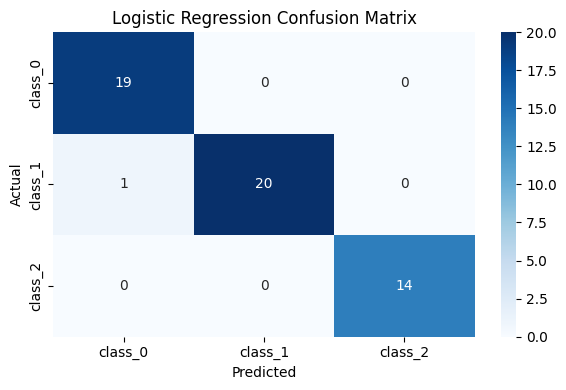

In [ ]:
# --- Model 1: Logistic Regression ---
print("\n--- 1. Logistic Regression (Classification) ---")
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear') # liblinear for OvR by default
lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)
y_proba_lr = lr_clf.predict_proba(X_test_scaled)
model_estimators_clf['Logistic Regression'] = lr_clf

accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, target_names=class_names, output_dict=True)
classification_results['Logistic Regression'] = {
    'accuracy': accuracy_lr,
    'weighted_f1': report_lr['weighted avg']['f1-score'],
    'macro_f1': report_lr['macro avg']['f1-score'],
    'y_pred': y_pred_lr,
    'y_proba': y_proba_lr
}
print(f"Accuracy: {accuracy_lr:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_lr, target_names=class_names))

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


--- 2. Support Vector Classifier (SVC) ---
Accuracy: 0.9815
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



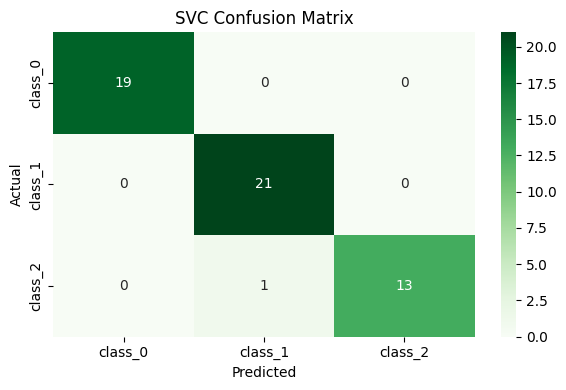

In [ ]:
# --- Model 2: Support Vector Classifier (SVC) ---
print("\n--- 2. Support Vector Classifier (SVC) ---")
from sklearn.svm import SVC
# SVC needs probability=True for predict_proba
svc_clf = SVC(random_state=42, probability=True)
svc_clf.fit(X_train_scaled, y_train)
y_pred_svc = svc_clf.predict(X_test_scaled)
y_proba_svc = svc_clf.predict_proba(X_test_scaled)
model_estimators_clf['SVC'] = svc_clf


accuracy_svc = accuracy_score(y_test, y_pred_svc)
report_svc = classification_report(y_test, y_pred_svc, target_names=class_names, output_dict=True)
classification_results['SVC'] = {
    'accuracy': accuracy_svc,
    'weighted_f1': report_svc['weighted avg']['f1-score'],
    'macro_f1': report_svc['macro avg']['f1-score'],
    'y_pred': y_pred_svc,
    'y_proba': y_proba_svc
}
print(f"Accuracy: {accuracy_svc:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_svc, target_names=class_names))

# Confusion Matrix for SVC
plt.figure(figsize=(6, 4))
cm_svc = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


--- 3. Decision Tree Classifier ---
Accuracy: 0.9630
Classification Report:
               precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



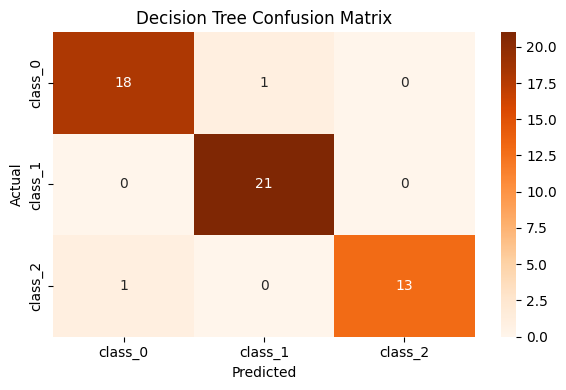

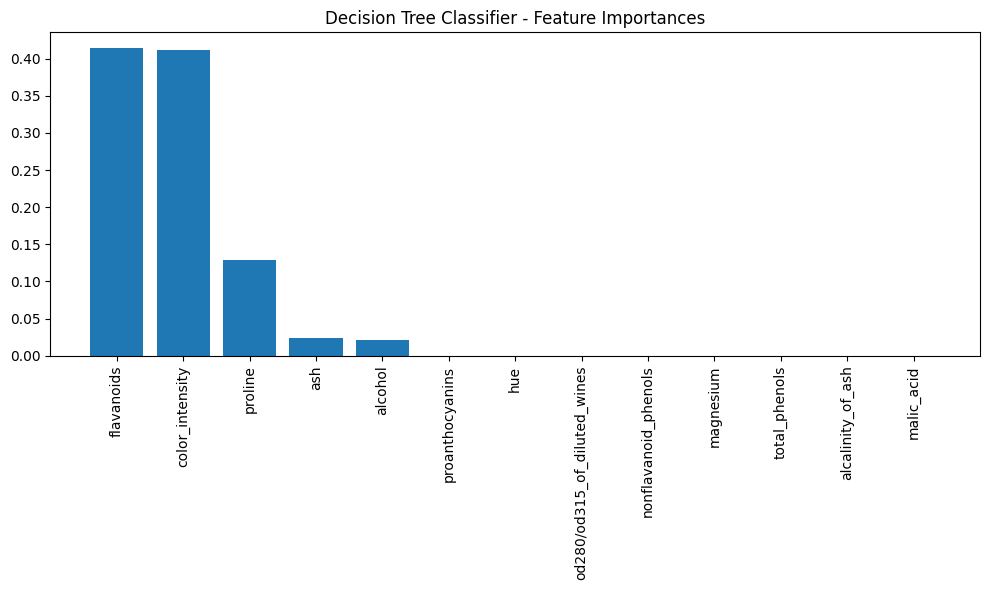

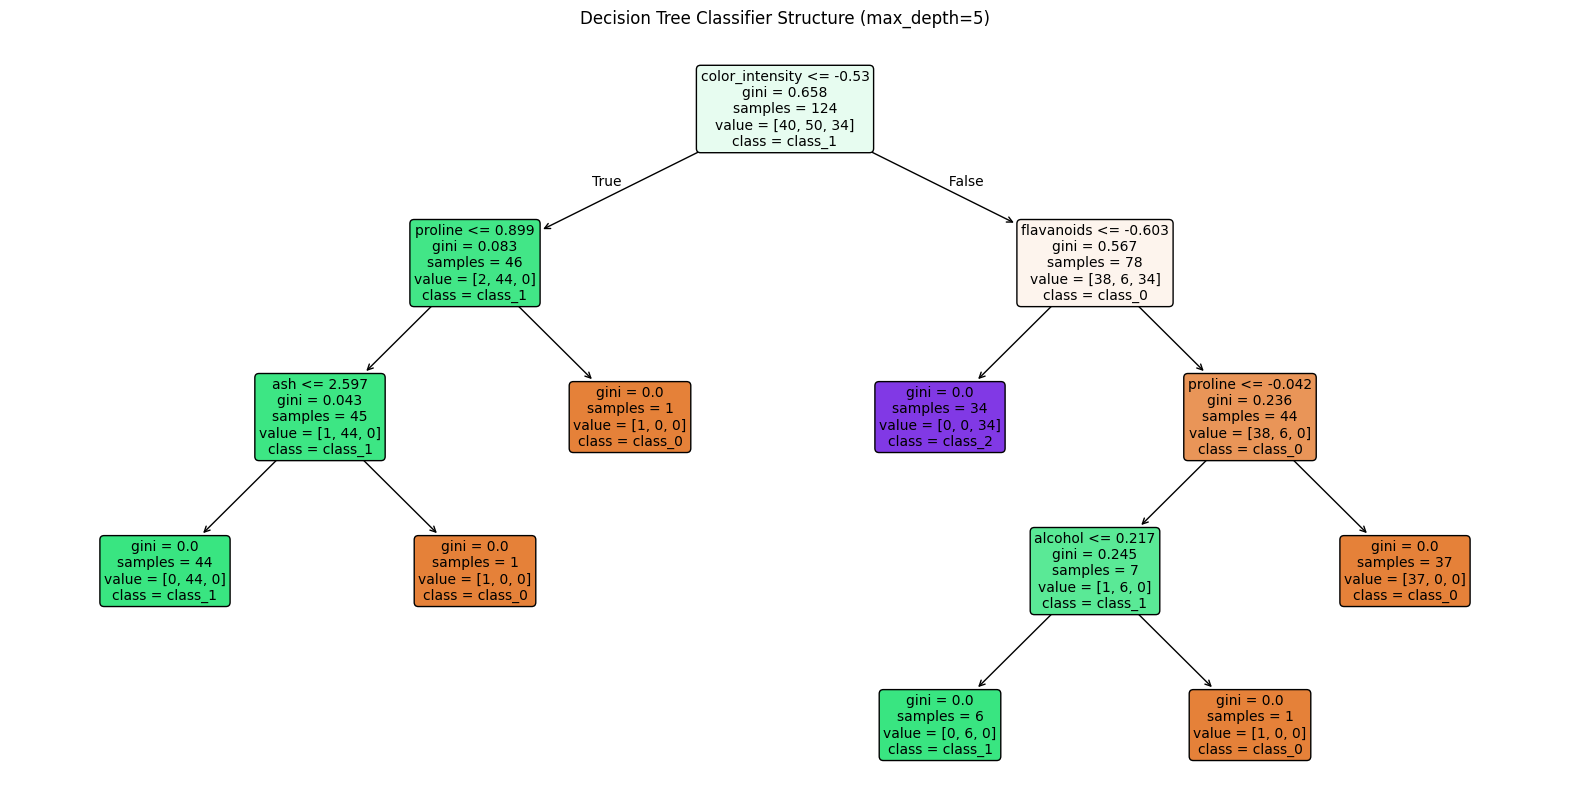

In [ ]:
# --- Model 3: Decision Tree Classifier ---
print("\n--- 3. Decision Tree Classifier ---")
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_scaled, y_train)
y_pred_dt = dt_clf.predict(X_test_scaled)
y_proba_dt = dt_clf.predict_proba(X_test_scaled)
model_estimators_clf['Decision Tree'] = dt_clf

accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, target_names=class_names, output_dict=True)
classification_results['Decision Tree'] = {
    'accuracy': accuracy_dt,
    'weighted_f1': report_dt['weighted avg']['f1-score'],
    'macro_f1': report_dt['macro avg']['f1-score'],
    'y_pred': y_pred_dt,
    'y_proba': y_proba_dt
}
print(f"Accuracy: {accuracy_dt:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_dt, target_names=class_names))

# Confusion Matrix for Decision Tree
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature Importance for Decision Tree Classifier
importances_dt = dt_clf.feature_importances_
indices_dt = np.argsort(importances_dt)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Decision Tree Classifier - Feature Importances")
plt.bar(range(X_train_scaled.shape[1]), importances_dt[indices_dt], align="center")
plt.xticks(range(X_train_scaled.shape[1]), np.array(feature_names)[indices_dt], rotation=90)
plt.xlim([-1, X_train_scaled.shape[1]])
plt.tight_layout()
plt.show()

# Visualize Decision Tree Classifier
plt.figure(figsize=(20,10)) # Adjust size as needed
plot_tree(dt_clf,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Classifier Structure (max_depth=5)")
plt.show()


--- 4. Random Forest Classifier ---
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



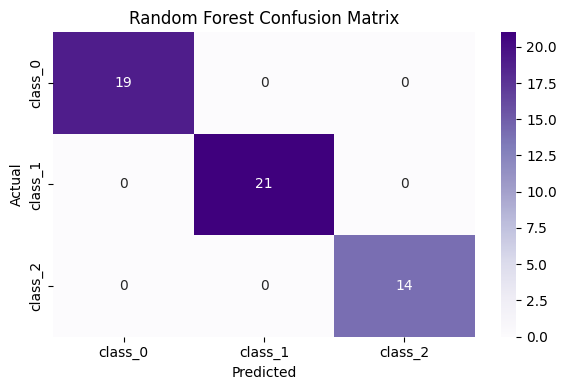

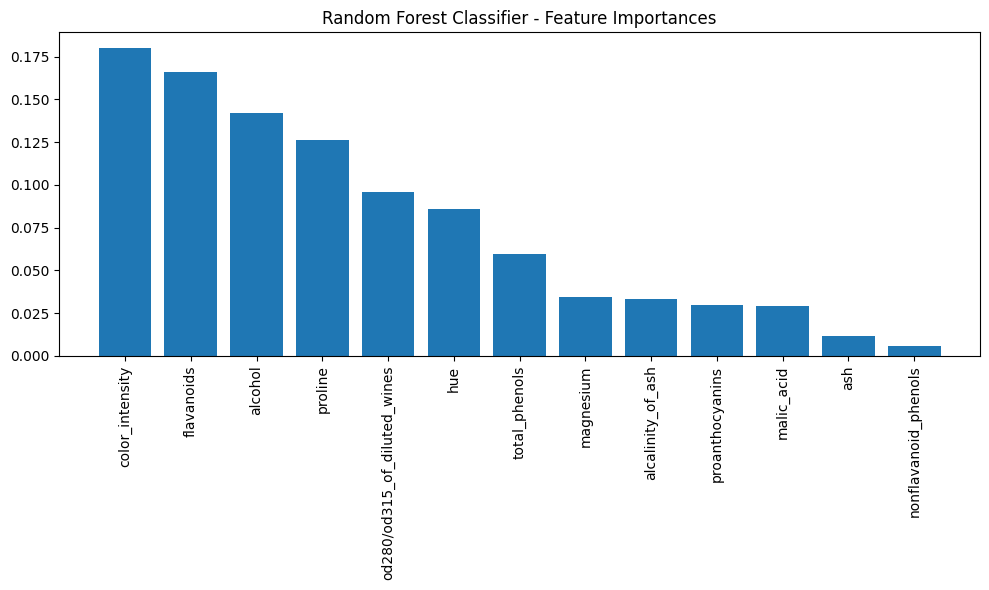

In [ ]:
# --- Model 4: Random Forest Classifier ---
print("\n--- 4. Random Forest Classifier ---")
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)
model_estimators_clf['Random Forest'] = rf_clf

accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, target_names=class_names, output_dict=True)
classification_results['Random Forest'] = {
    'accuracy': accuracy_rf,
    'weighted_f1': report_rf['weighted avg']['f1-score'],
    'macro_f1': report_rf['macro avg']['f1-score'],
    'y_pred': y_pred_rf,
    'y_proba': y_proba_rf
}
print(f"Accuracy: {accuracy_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf, target_names=class_names))

# Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature Importance for Random Forest Classifier
importances_rf = rf_clf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Random Forest Classifier - Feature Importances")
plt.bar(range(X_train_scaled.shape[1]), importances_rf[indices_rf], align="center")
plt.xticks(range(X_train_scaled.shape[1]), np.array(feature_names)[indices_rf], rotation=90)
plt.xlim([-1, X_train_scaled.shape[1]])
plt.tight_layout()
plt.show()


--- 5. K-Nearest Neighbors (KNN) Classifier ---
Accuracy: 0.9630
Classification Report:
               precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.90      0.95        21
     class_2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



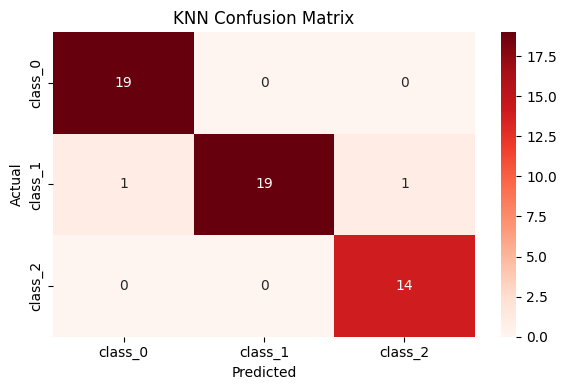

In [ ]:
# --- Model 5: K-Nearest Neighbors Classifier ---
print("\n--- 5. K-Nearest Neighbors (KNN) Classifier ---")
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)
y_proba_knn = knn_clf.predict_proba(X_test_scaled)
model_estimators_clf['KNN'] = knn_clf

accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn, target_names=class_names, output_dict=True)
classification_results['KNN'] = {
    'accuracy': accuracy_knn,
    'weighted_f1': report_knn['weighted avg']['f1-score'],
    'macro_f1': report_knn['macro avg']['f1-score'],
    'y_pred': y_pred_knn,
    'y_proba': y_proba_knn
}
print(f"Accuracy: {accuracy_knn:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_knn, target_names=class_names))

# Confusion Matrix for KNN
plt.figure(figsize=(6, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


--- COMPARISON OF CLASSIFICATION MODELS ---


<ipython-input-24-df8bc702eef8>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_clf, y=accuracies, palette='viridis')


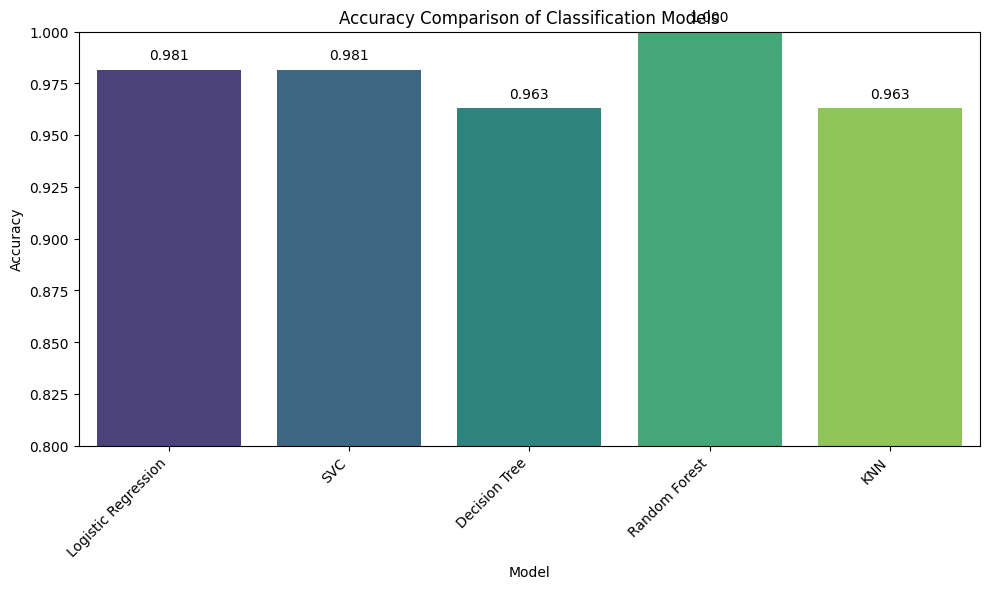

<ipython-input-24-df8bc702eef8>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_clf, y=weighted_f1_scores, palette='mako')


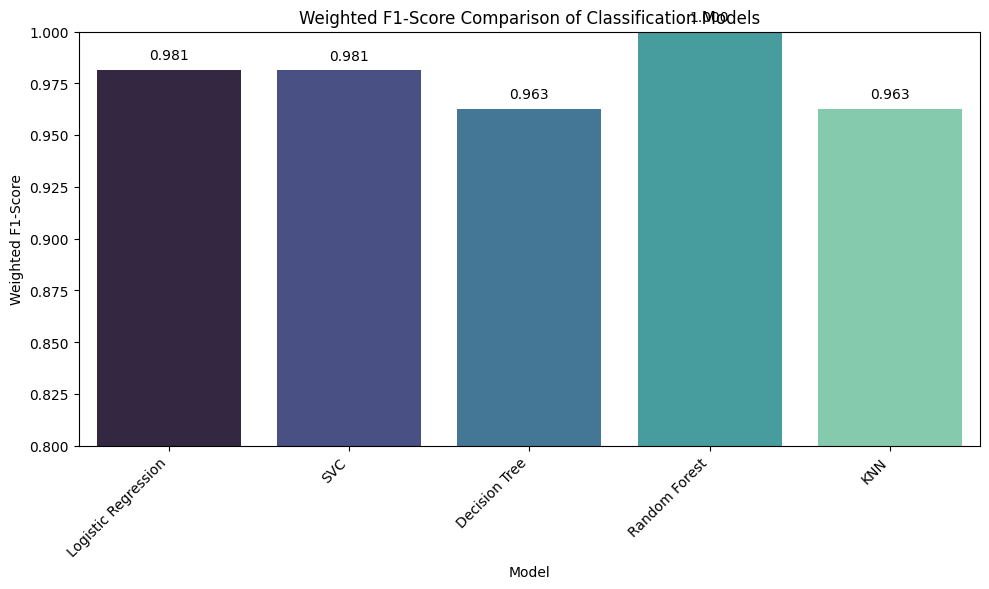

<ipython-input-24-df8bc702eef8>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_clf, y=macro_f1_scores, palette='rocket')


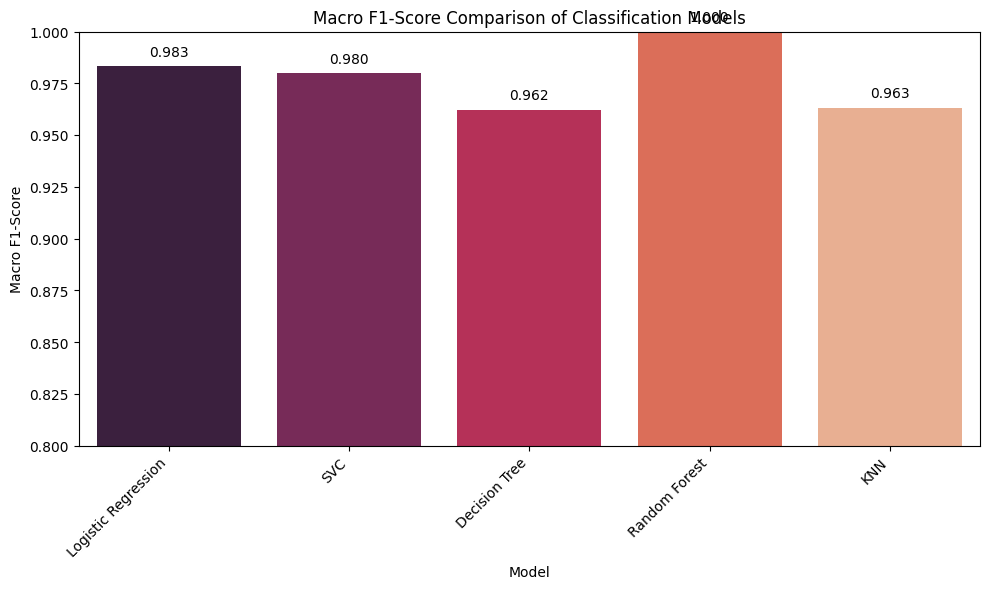

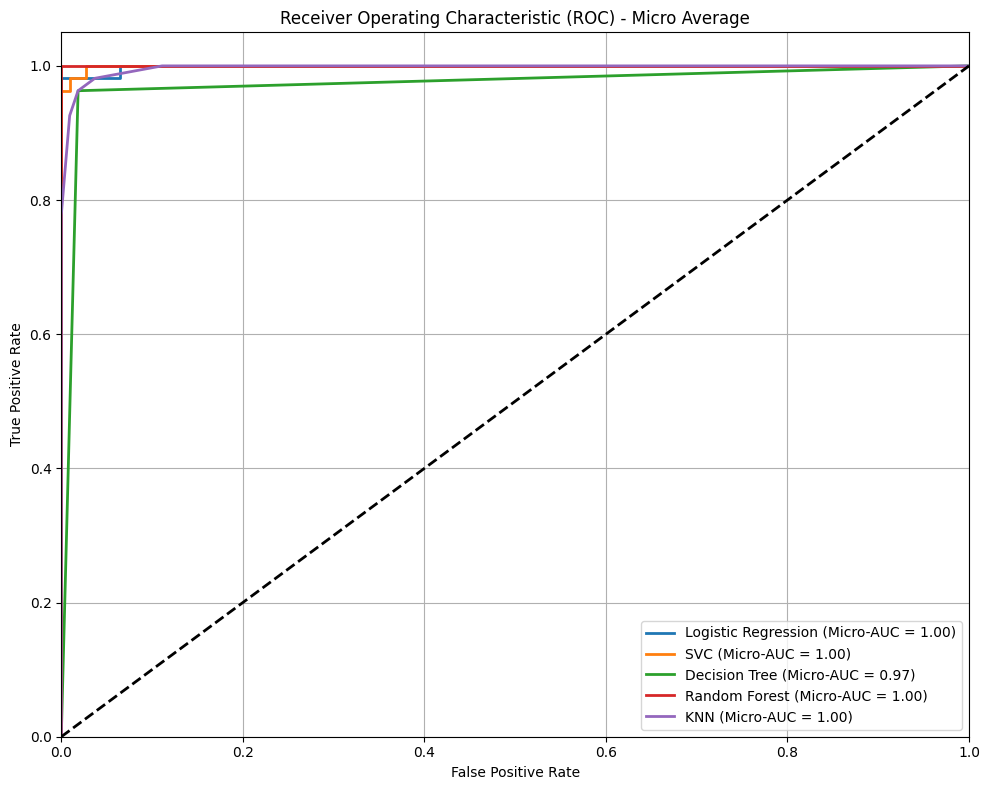

In [ ]:
# --- Comparison Visualizations for Classification Models ---
print("\n--- COMPARISON OF CLASSIFICATION MODELS ---")

# 1. Accuracy Comparison
model_names_clf = list(classification_results.keys())
accuracies = [classification_results[model]['accuracy'] for model in model_names_clf]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_clf, y=accuracies, palette='viridis')
plt.title('Accuracy Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0) # Adjust ylim for better visualization if accuracies are high
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.3f}", color='black', ha='center')
plt.tight_layout()
plt.show()

# 2. Weighted F1-Score Comparison
weighted_f1_scores = [classification_results[model]['weighted_f1'] for model in model_names_clf]
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_clf, y=weighted_f1_scores, palette='mako')
plt.title('Weighted F1-Score Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Weighted F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)
for i, v in enumerate(weighted_f1_scores):
    plt.text(i, v + 0.005, f"{v:.3f}", color='black', ha='center')
plt.tight_layout()
plt.show()

# 3. Macro F1-Score Comparison
macro_f1_scores = [classification_results[model]['macro_f1'] for model in model_names_clf]
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_clf, y=macro_f1_scores, palette='rocket')
plt.title('Macro F1-Score Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Macro F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)
for i, v in enumerate(macro_f1_scores):
    plt.text(i, v + 0.005, f"{v:.3f}", color='black', ha='center')
plt.tight_layout()
plt.show()


# 4. ROC Curves Comparison (One-vs-Rest for each class, then averaged)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))
for model_name, results in classification_results.items():
    y_proba = results['y_proba']
    # Micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (Micro-AUC = {roc_auc:.2f})', lw=2)

    # Macro-average ROC (OvR)
    # fpr_macro = dict()
    # tpr_macro = dict()
    # roc_auc_macro = dict()
    # all_fpr = np.unique(np.concatenate([roc_curve(y_test_binarized[:, i], y_proba[:, i])[0] for i in range(n_classes)]))
    # mean_tpr = np.zeros_like(all_fpr)
    # for i in range(n_classes):
    #     fpr_class, tpr_class, _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
    #     mean_tpr += np.interp(all_fpr, fpr_class, tpr_class)
    # mean_tpr /= n_classes
    # roc_auc_val_macro = auc(all_fpr, mean_tpr)
    # plt.plot(all_fpr, mean_tpr, linestyle=':', label=f'{model_name} (Macro-AUC = {roc_auc_val_macro:.2f})', lw=2)


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Micro Average')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

####REGRESSION


In [ ]:
# Store results for comparison
regression_results = {}


--- 1. Linear Regression ---
MSE: 0.0598, MAE: 0.1911, R2 Score: 0.9008


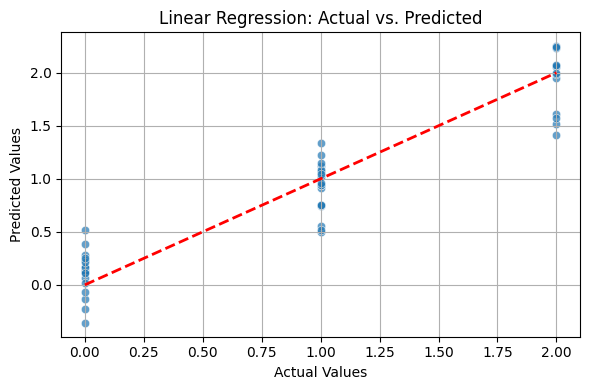

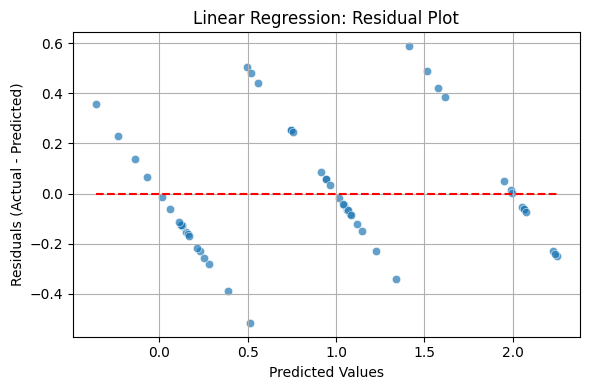

In [ ]:
# --- Model 1: Linear Regression ---
print("\n--- 1. Linear Regression ---")
from sklearn.linear_model import LinearRegression
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train)
y_pred_lr_reg = lr_reg.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr_reg)
mae_lr = mean_absolute_error(y_test, y_pred_lr_reg)
r2_lr = r2_score(y_test, y_pred_lr_reg)
regression_results['Linear Regression'] = {'mse': mse_lr, 'mae': mae_lr, 'r2': r2_lr, 'y_pred': y_pred_lr_reg}
print(f"MSE: {mse_lr:.4f}, MAE: {mae_lr:.4f}, R2 Score: {r2_lr:.4f}")

# Actual vs. Predicted Plot
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_lr_reg, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs. Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals_lr = y_test - y_pred_lr_reg
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_lr_reg, residuals_lr, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.hlines(0, xmin=min(y_pred_lr_reg), xmax=max(y_pred_lr_reg), colors='r', linestyles='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Linear Regression: Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()



--- 2. Support Vector Regressor (SVR) ---
MSE: 0.0437, MAE: 0.1459, R2 Score: 0.9274


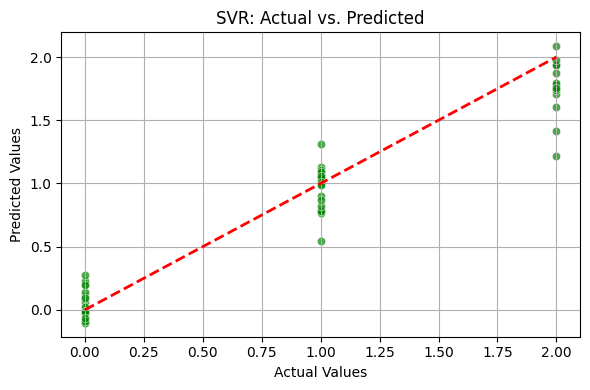

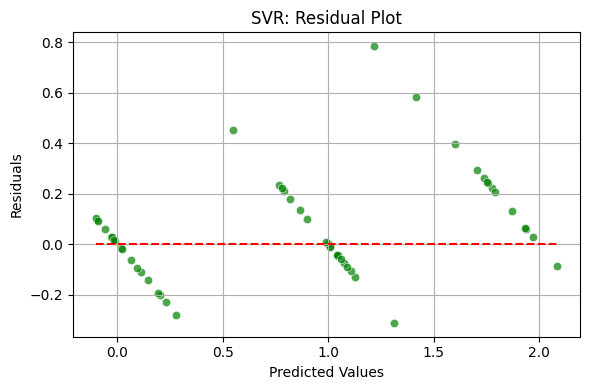

In [ ]:
# --- Model 2: Support Vector Regressor (SVR) ---
print("\n--- 2. Support Vector Regressor (SVR) ---")
from sklearn.svm import SVR
svr_reg = SVR()
svr_reg.fit(X_train_scaled, y_train)
y_pred_svr_reg = svr_reg.predict(X_test_scaled)

mse_svr = mean_squared_error(y_test, y_pred_svr_reg)
mae_svr = mean_absolute_error(y_test, y_pred_svr_reg)
r2_svr = r2_score(y_test, y_pred_svr_reg)
regression_results['SVR'] = {'mse': mse_svr, 'mae': mae_svr, 'r2': r2_svr, 'y_pred': y_pred_svr_reg}
print(f"MSE: {mse_svr:.4f}, MAE: {mae_svr:.4f}, R2 Score: {r2_svr:.4f}")

# Actual vs. Predicted Plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_svr_reg, alpha=0.7, color='green', edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs. Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals_svr = y_test - y_pred_svr_reg
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_svr_reg, residuals_svr, alpha=0.7, color='green', edgecolors='w', linewidth=0.5)
plt.hlines(0, xmin=min(y_pred_svr_reg), xmax=max(y_pred_svr_reg), colors='r', linestyles='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("SVR: Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()



--- 3. Decision Tree Regressor ---
MSE: 0.1481, MAE: 0.1111, R2 Score: 0.7541


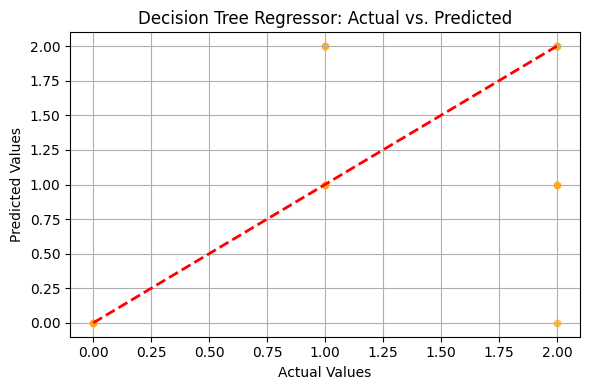

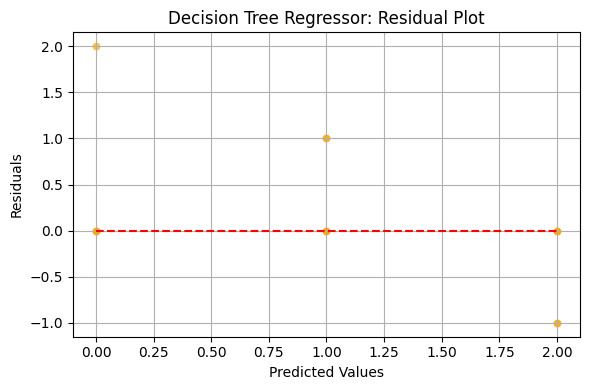

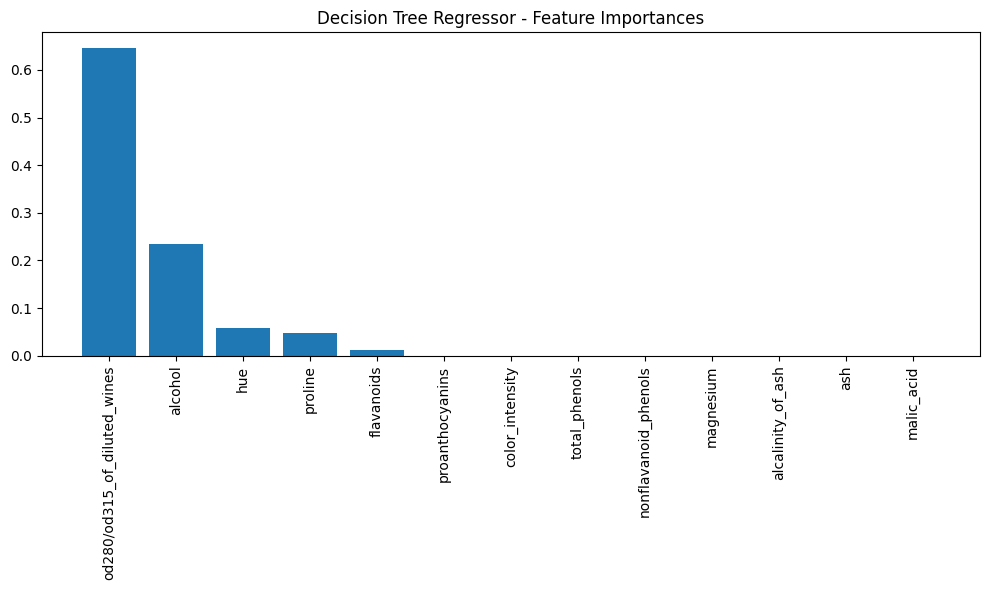

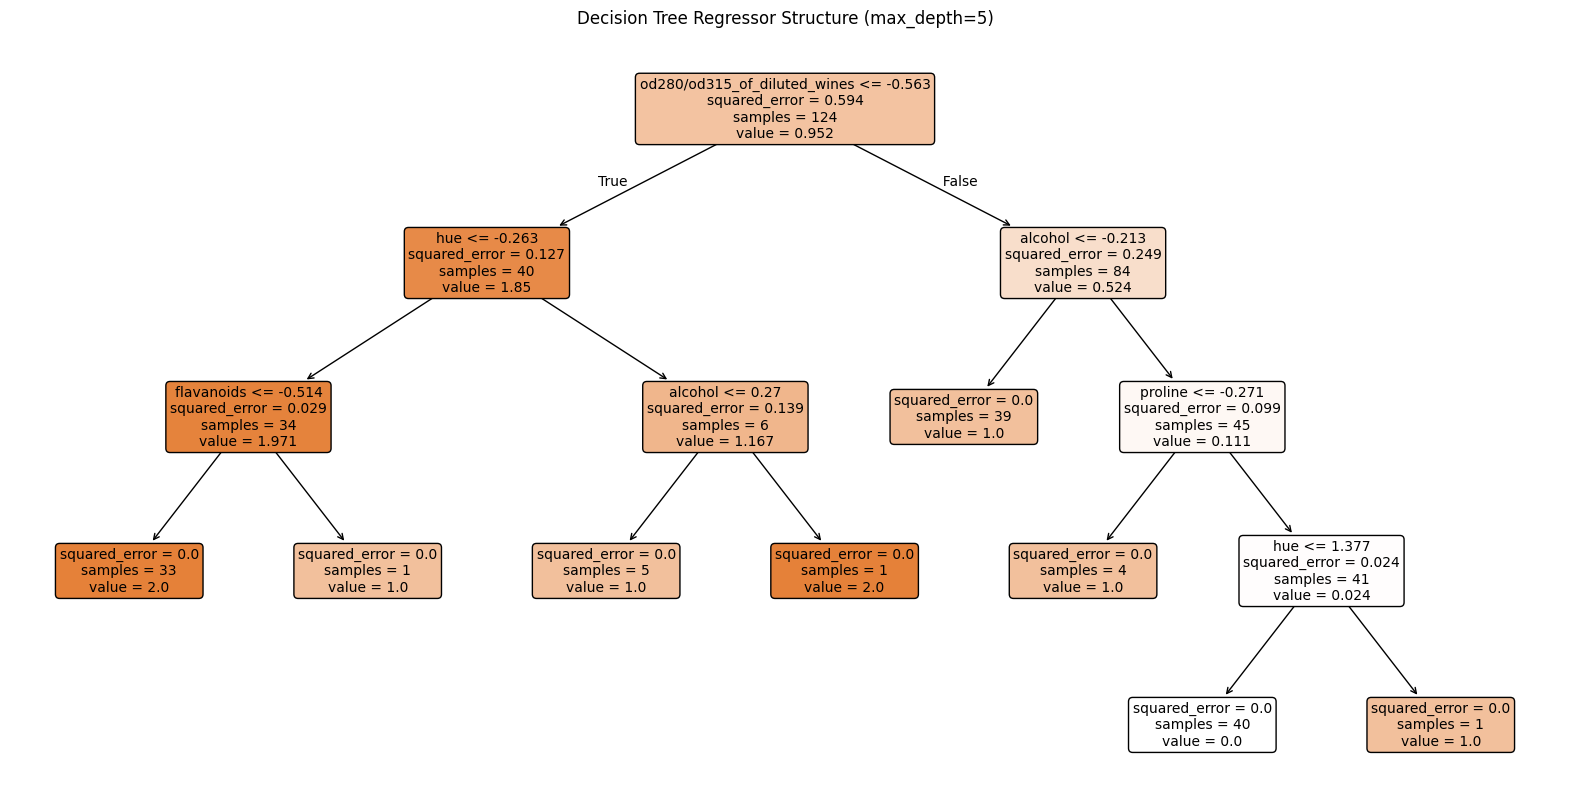

In [ ]:
# --- Model 3: Decision Tree Regressor ---
print("\n--- 3. Decision Tree Regressor ---")
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(random_state=42, max_depth=5) # Added max_depth
dt_reg.fit(X_train_scaled, y_train)
y_pred_dt_reg = dt_reg.predict(X_test_scaled)

mse_dt = mean_squared_error(y_test, y_pred_dt_reg)
mae_dt = mean_absolute_error(y_test, y_pred_dt_reg)
r2_dt = r2_score(y_test, y_pred_dt_reg)
regression_results['Decision Tree Regressor'] = {
    'mse': mse_dt, 'mae': mae_dt, 'r2': r2_dt, 'y_pred': y_pred_dt_reg,
    'feature_importances': dt_reg.feature_importances_
}
print(f"MSE: {mse_dt:.4f}, MAE: {mae_dt:.4f}, R2 Score: {r2_dt:.4f}")

# Actual vs. Predicted & Residual Plots (same as before)
plt.figure(figsize=(6,4)); plt.scatter(y_test, y_pred_dt_reg, alpha=0.7, color='orange', edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel("Actual Values"); plt.ylabel("Predicted Values"); plt.title("Decision Tree Regressor: Actual vs. Predicted")
plt.grid(True); plt.tight_layout(); plt.show()
residuals_dt = y_test - y_pred_dt_reg
plt.figure(figsize=(6, 4)); plt.scatter(y_pred_dt_reg, residuals_dt, alpha=0.7, color='orange', edgecolors='w', linewidth=0.5)
plt.hlines(0, xmin=min(y_pred_dt_reg), xmax=max(y_pred_dt_reg), colors='r', linestyles='--')
plt.xlabel("Predicted Values"); plt.ylabel("Residuals"); plt.title("Decision Tree Regressor: Residual Plot")
plt.grid(True); plt.tight_layout(); plt.show()

# Feature Importance for Decision Tree Regressor
importances_dt_reg = dt_reg.feature_importances_
indices_dt_reg = np.argsort(importances_dt_reg)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Decision Tree Regressor - Feature Importances")
plt.bar(range(X_train_scaled.shape[1]), importances_dt_reg[indices_dt_reg], align="center")
plt.xticks(range(X_train_scaled.shape[1]), np.array(feature_names)[indices_dt_reg], rotation=90)
plt.xlim([-1, X_train_scaled.shape[1]])
plt.tight_layout()
plt.show()

# Visualize Decision Tree Regressor
plt.figure(figsize=(20,10)) # Adjust size as needed
plot_tree(dt_reg,
          feature_names=feature_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Regressor Structure (max_depth=5)")
plt.show()


--- 4. Random Forest Regressor ---
MSE: 0.0572, MAE: 0.1146, R2 Score: 0.9050


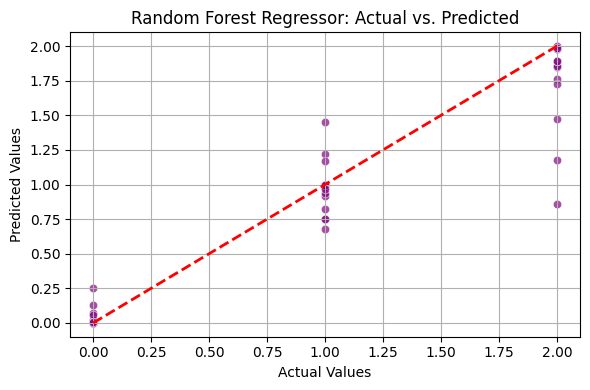

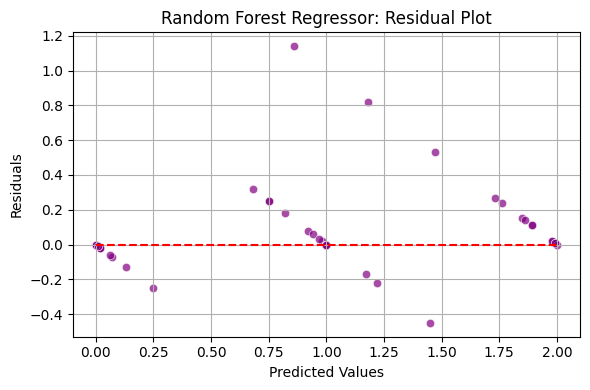

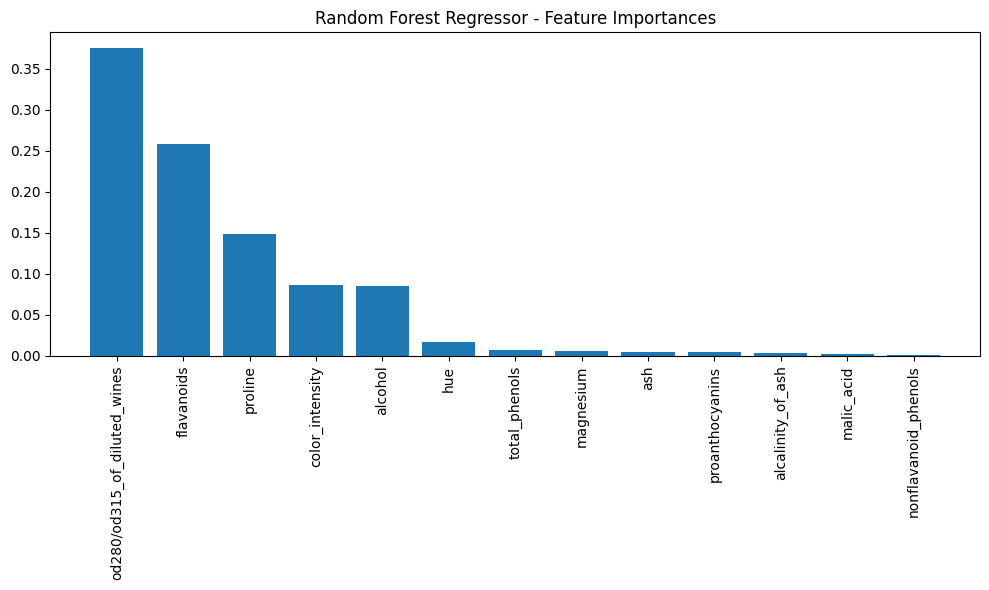

In [ ]:
# --- Model 4: Random Forest Regressor ---
print("\n--- 4. Random Forest Regressor ---")
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

mse_rf = mean_squared_error(y_test, y_pred_rf_reg)
mae_rf = mean_absolute_error(y_test, y_pred_rf_reg)
r2_rf = r2_score(y_test, y_pred_rf_reg)
regression_results['Random Forest Regressor'] = {
    'mse': mse_rf, 'mae': mae_rf, 'r2': r2_rf, 'y_pred': y_pred_rf_reg,
    'feature_importances': rf_reg.feature_importances_
}
print(f"MSE: {mse_rf:.4f}, MAE: {mae_rf:.4f}, R2 Score: {r2_rf:.4f}")

# Actual vs. Predicted & Residual Plot
plt.figure(figsize=(6,4)); plt.scatter(y_test, y_pred_rf_reg, alpha=0.7, color='purple', edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel("Actual Values"); plt.ylabel("Predicted Values"); plt.title("Random Forest Regressor: Actual vs. Predicted")
plt.grid(True); plt.tight_layout(); plt.show()
residuals_rf = y_test - y_pred_rf_reg
plt.figure(figsize=(6, 4)); plt.scatter(y_pred_rf_reg, residuals_rf, alpha=0.7, color='purple', edgecolors='w', linewidth=0.5)
plt.hlines(0, xmin=min(y_pred_rf_reg), xmax=max(y_pred_rf_reg), colors='r', linestyles='--')
plt.xlabel("Predicted Values"); plt.ylabel("Residuals"); plt.title("Random Forest Regressor: Residual Plot")
plt.grid(True); plt.tight_layout(); plt.show()

# Feature Importance for Random Forest Regressor
importances_rf_reg = rf_reg.feature_importances_
indices_rf_reg = np.argsort(importances_rf_reg)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Random Forest Regressor - Feature Importances")
plt.bar(range(X_train_scaled.shape[1]), importances_rf_reg[indices_rf_reg], align="center")
plt.xticks(range(X_train_scaled.shape[1]), np.array(feature_names)[indices_rf_reg], rotation=90)
plt.xlim([-1, X_train_scaled.shape[1]])
plt.tight_layout()
plt.show()


--- 5. K-Nearest Neighbors (KNN) Regressor ---
MSE: 0.0304, MAE: 0.0704, R2 Score: 0.9496


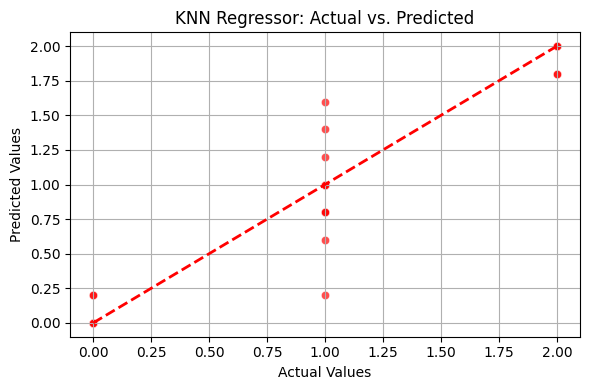

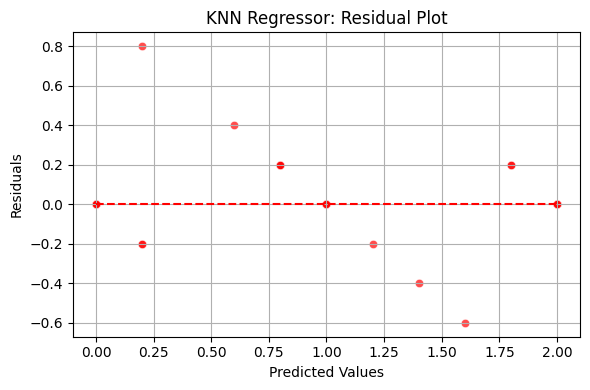

In [ ]:
# --- Model 5: K-Nearest Neighbors Regressor ---
print("\n--- 5. K-Nearest Neighbors (KNN) Regressor ---")
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred_knn_reg = knn_reg.predict(X_test_scaled)

mse_knn = mean_squared_error(y_test, y_pred_knn_reg)
mae_knn = mean_absolute_error(y_test, y_pred_knn_reg)
r2_knn = r2_score(y_test, y_pred_knn_reg)
regression_results['KNN Regressor'] = {'mse': mse_knn, 'mae': mae_knn, 'r2': r2_knn, 'y_pred': y_pred_knn_reg}
print(f"MSE: {mse_knn:.4f}, MAE: {mae_knn:.4f}, R2 Score: {r2_knn:.4f}")

# Actual vs. Predicted Plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_knn_reg, alpha=0.7, color='red', edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN Regressor: Actual vs. Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals_knn = y_test - y_pred_knn_reg
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_knn_reg, residuals_knn, alpha=0.7, color='red', edgecolors='w', linewidth=0.5)
plt.hlines(0, xmin=min(y_pred_knn_reg), xmax=max(y_pred_knn_reg), colors='r', linestyles='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("KNN Regressor: Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


--- COMPARISON OF REGRESSION MODELS ---


<ipython-input-31-6dfdd89dd61f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_reg, y=r2_scores_reg, palette='crest')


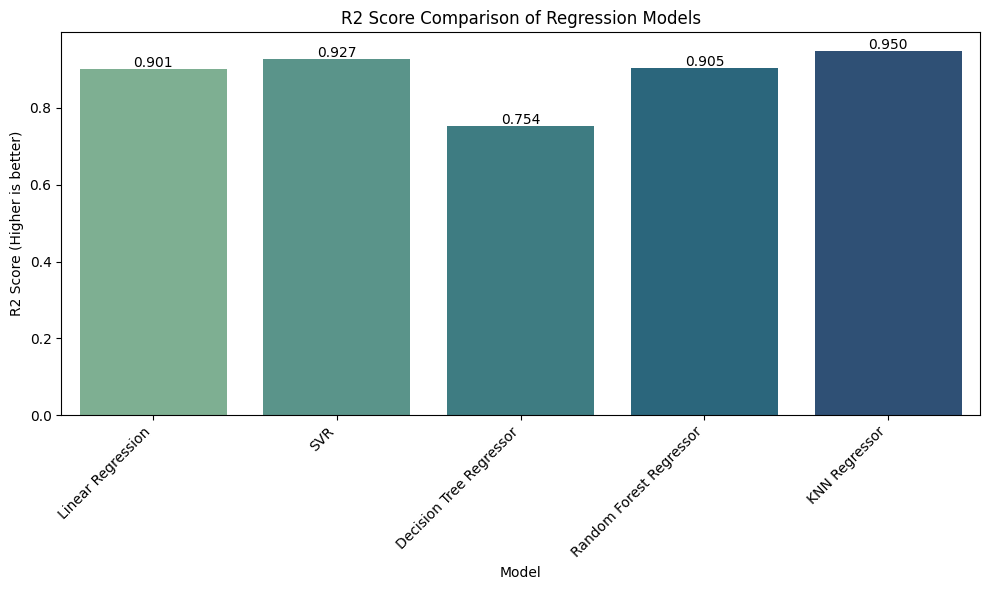

<ipython-input-31-6dfdd89dd61f>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_reg, y=mse_scores_reg, palette='flare')


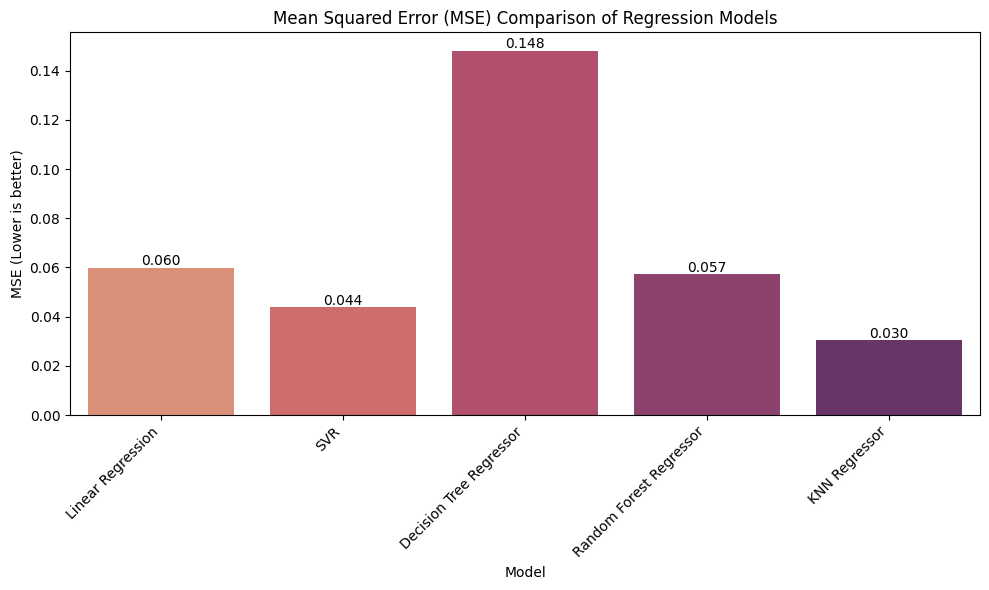

<ipython-input-31-6dfdd89dd61f>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_reg, y=mae_scores_reg, palette='cubehelix')


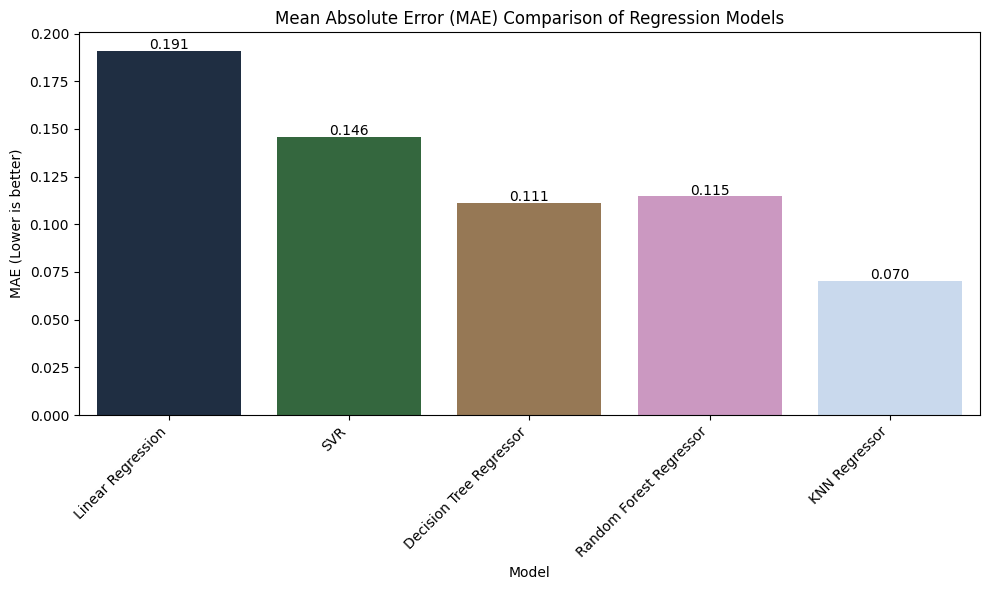

In [ ]:
# --- Comparison Visualizations for Regression Models ---
print("\n--- COMPARISON OF REGRESSION MODELS ---")

model_names_reg = list(regression_results.keys())

# 1. R2 Score Comparison
r2_scores_reg = [regression_results[model]['r2'] for model in model_names_reg]
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_reg, y=r2_scores_reg, palette='crest')
plt.title('R2 Score Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R2 Score (Higher is better)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(r2_scores_reg):
    plt.text(i, v + 0.005 if v >= 0 else v - 0.03, f"{v:.3f}", color='black', ha='center')
plt.tight_layout()
plt.show()

# 2. Mean Squared Error (MSE) Comparison
mse_scores_reg = [regression_results[model]['mse'] for model in model_names_reg]
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_reg, y=mse_scores_reg, palette='flare')
plt.title('Mean Squared Error (MSE) Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('MSE (Lower is better)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(mse_scores_reg):
    plt.text(i, v + 0.001, f"{v:.3f}", color='black', ha='center')
plt.tight_layout()
plt.show()

# 3. Mean Absolute Error (MAE) Comparison
mae_scores_reg = [regression_results[model]['mae'] for model in model_names_reg]
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_reg, y=mae_scores_reg, palette='cubehelix')
plt.title('Mean Absolute Error (MAE) Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('MAE (Lower is better)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(mae_scores_reg):
    plt.text(i, v + 0.001, f"{v:.3f}", color='black', ha='center')
plt.tight_layout()
plt.show()


